In [ ]:
from fredapi import Fred
import yfinance as yf
from fred_api_key import API_KEY
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

[*********************100%***********************]  1 of 1 completed


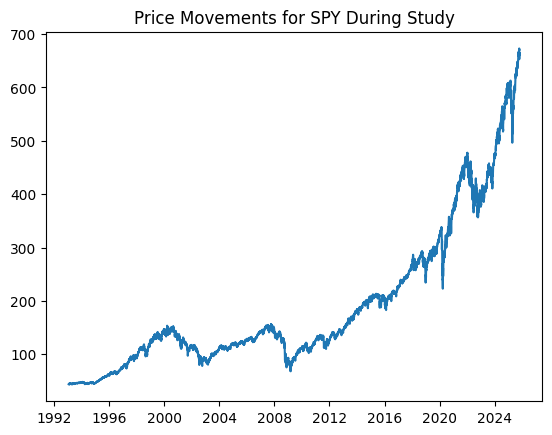

In [66]:
TICKER = 'SPY'
INTERVAL = '1d'
PERIOD = '730d' if INTERVAL == '1h' else 'max'

LOOKBACK = 10000
fred = Fred(api_key=API_KEY)

def get_data(ticker=TICKER, lookback=LOOKBACK, interval=INTERVAL):
    df = yf.download(ticker, interval=interval, auto_adjust=False, period=PERIOD, group_by='column')
    df.columns = df.columns.get_level_values(0)

    df['Asset_Returns'] = (1 + df['Close'].pct_change()).cumprod() - 1

    # only return the subset of data you are interested in
    subset = df.iloc[-lookback:, :]
    plt.figure()
    plt.plot(subset['Close'])
    plt.title(f'Price Movements for {ticker} During Study')

    return subset.dropna()

def add_interest_rates(df):
    fedfunds = pd.DataFrame(fred.get_series('DFF'), columns=['FedFunds'])
    combined = pd.concat([df, fedfunds], axis=1) 
    return combined

def main():
    df = get_data()
    df = add_interest_rates(df)
    return df

df = main()

In [73]:
df = df.dropna()

Text(0.5, 1.0, 'Yfinance Price Info, FRED Interest Rate Info')

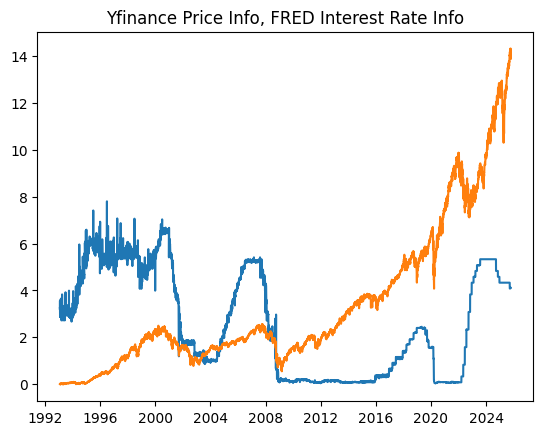

In [ ]:
plt.plot(df['FedFunds'])
plt.plot(df['Asset_Returns'])
plt.title('Yfinance Price Info, FRED Interest Rate Info')